In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import nbinom
from scipy.stats import poisson as poisson_dist
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats


In [ ]:
worker_comp_freq = pd.read_excel("cleaned_datasets/worker_comp_freq.xlsx")
worker_comp_sev = pd.read_excel("cleaned_datasets/worker_comp_sev.xlsx")
equipment_failure_freq = pd.read_excel("cleaned_datasets/equipment_failure_freq.xlsx")
equipment_failure_sev = pd.read_excel("cleaned_datasets/equipment_failure_sev.xlsx")
cargo_loss_freq = pd.read_excel("cleaned_datasets/cargo_loss_freq.xlsx")
cargo_loss_sev = pd.read_excel("cleaned_datasets/cargo_loss_sev.xlsx")
business_interruptions_freq = pd.read_excel("cleaned_datasets/business_interruptions_freq.xlsx")
business_interruptions_sev = pd.read_excel("cleaned_datasets/business_interruptions_sev.xlsx")

# Frequency

In [ ]:
frequency_datasets = {
    "Business Interruption": business_interruptions_freq["claim_count"],
    "Cargo Loss": cargo_loss_freq["claim_count"],
    "Equipment Failure": equipment_failure_freq["claim_count"],
    "Worker Compensation": worker_comp_freq["claim_count"],
}

### Variance vs Mean

In [ ]:
def compute_basic_stats(data, name):
    mean = np.mean(data)
    variance = np.var(data)
    zeros = (data == 0).mean()

    print(f'{name} ratio = ', round(variance/mean,2))
    print(f'{name} zero percentage = ', round(zeros,2))
    print()
    return [name, round(zeros,2), round(variance/mean,2)]

Business Interruption ratio =  1.72
Business Interruption zero percentage =  0.93

Cargo Loss ratio =  1.43
Cargo Loss zero percentage =  0.82

Equipment Failure ratio =  1.04
Equipment Failure zero percentage =  0.93

Worker Compensation ratio =  1.01
Worker Compensation zero percentage =  0.99



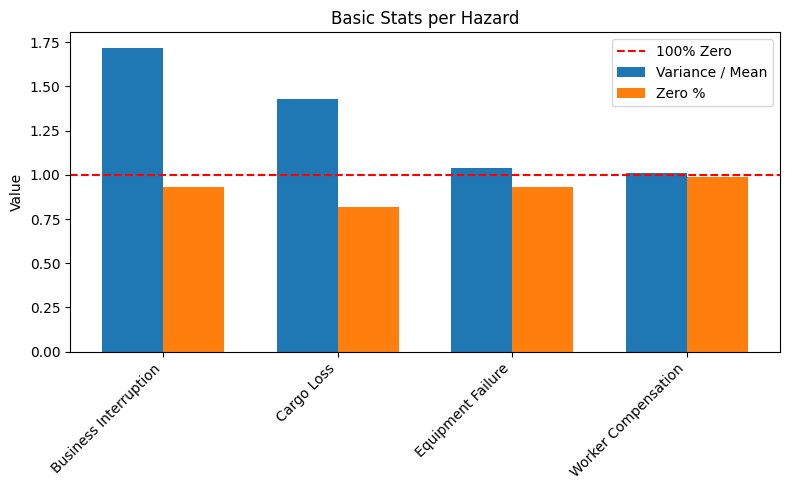

In [ ]:
def plot_basic_stats(frequency_datasets):
    stats_list = []

    for name, hazard in frequency_datasets.items():
        stats_list.append(compute_basic_stats(hazard, name))

    stats_df = pd.DataFrame(stats_list, columns=["Hazard", "Zero_%","Var/Mean"])

    # Set up bar positions
    x = np.arange(len(stats_df))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8,5))

    ax.bar(x - width/2, stats_df['Var/Mean'], width, label='Variance / Mean')
    ax.bar(x + width/2, stats_df['Zero_%'], width, label='Zero %')
    ax.axhline(y=1, color='red', linestyle='--', label='100% Zero')


    ax.set_xticks(x)
    ax.set_xticklabels(stats_df['Hazard'], rotation=45, ha='right')
    ax.set_ylabel("Value")
    ax.set_title("Basic Stats per Hazard")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_basic_stats(frequency_datasets)

Business Interruption (1.72) and Cargo Loss (1.43) exhibit moderate overdispersion, indicating that the variance exceeds the mean and suggesting that alternative models such as the Negative Binomial may provide a better fit. Equipment Failure (1.04) and Worker Compensation (1.01) have ratios close to one, indicating that the Poisson assumption is reasonable for these hazards.

Additionally, all hazards show a high proportion of zero claims (82%–99%), which is typical in insurance data. Despite this being typical and expected in insurance, we can investigate if its structural or typical insurance data

## Structural or Typical Zero's?

In [ ]:
def plot_rootogram(observed_counts, fitted_counts, ax, title="Rootogram"):
    """
    observed_counts: Pandas Series or array of observed frequencies
    fitted_counts: array of expected frequencies
    ax: matplotlib axis to draw the plot on
    """

    k = np.arange(len(observed_counts))

    ax.bar(k, np.sqrt(observed_counts), width=0.4, label="Observed")
    ax.bar(k + 0.4, np.sqrt(fitted_counts), width=0.4, label="Fitted")

    ax.set_xlabel("Claim Count")
    ax.set_ylabel("Sqrt(Frequency)")
    ax.set_title(title)
    ax.legend()

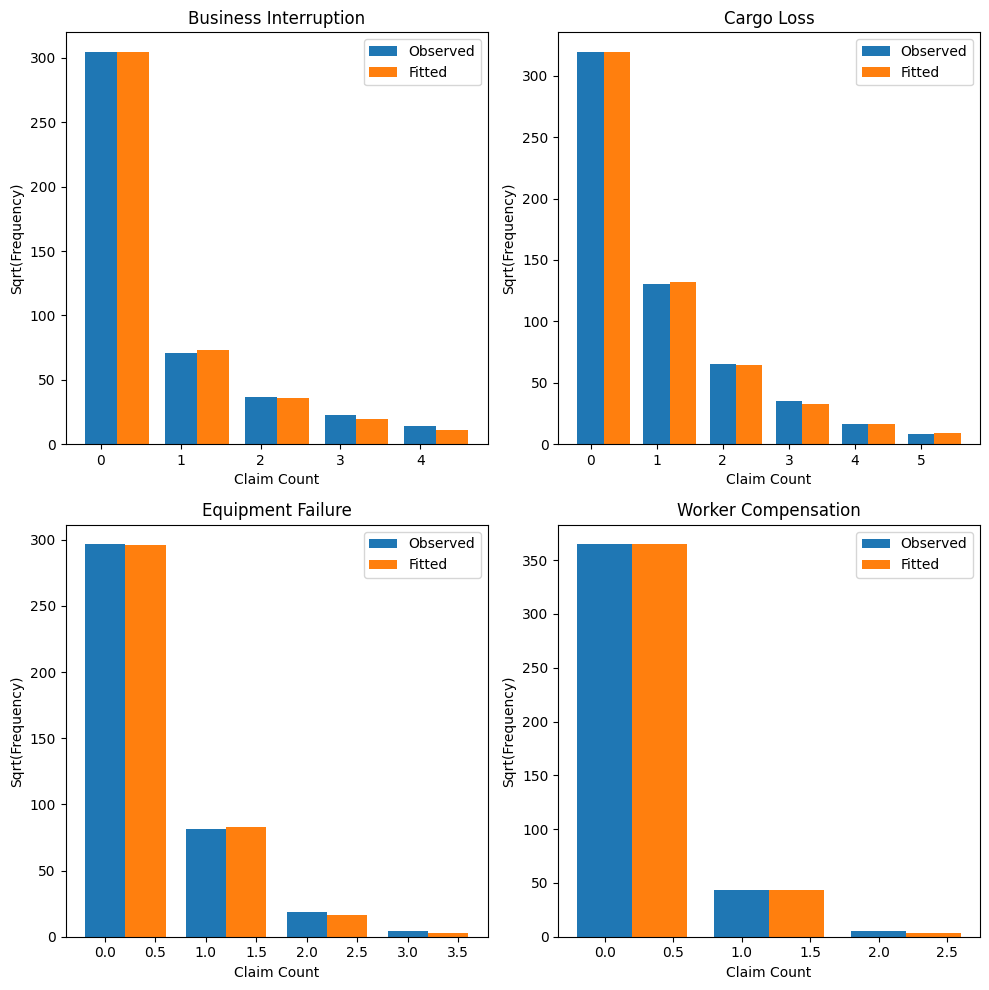

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.flatten()

def run_rootogram(data,name, ax):
    """
    data: claim_count for each hazard dataset
    name: the name of the hazard/dataset
    """
    data = data.dropna().astype(int)

    # Observed frequencies
    obs_freq = data.value_counts().sort_index()
    k_max = obs_freq.index.max()
    obs_freq = obs_freq.reindex(np.arange(0, k_max+1), fill_value=0)

    # Fit Poisson or NB
    # Mean
    mu = data.mean()
    # Variance
    variance = data.var()

    if variance / mu > 1.1:             # if overdispersed, then negative binomial model
        r = mu**2 / (variance - mu)
        p = r / (r + mu)
        # Fit NB Model
        fitted_nb = nbinom.pmf(np.arange(k_max+1), r, p) * len(data)
        # Visalize
        plot_rootogram(obs_freq.values, fitted_nb, ax=ax, title=f"{name}")
    else:                               # if mean almost equal to variance, then Poisson model
        # Fit poisson model
        fitted_poisson = poisson_dist.pmf(np.arange(k_max+1), mu) * len(data)
        # Visalize
        plot_rootogram(obs_freq.values, fitted_poisson, ax=ax, title=f"{name}")

for i, (name, hazard) in enumerate(frequency_datasets.items()):
    run_rootogram(hazard, name, ax=axes[i])
plt.tight_layout()
plt.show()

The zeros were predicted and handled by the models, so therefore we do not need zero-inflated model

We can proceed with either Negative Binomial or Poisson.

## Choosing the Correct Model

(a,b,0) class diagnostic is a family of distribution that examines the ratio of successive probabilities of recurisve discrete non-negative numbers (claim_count)

In [ ]:
# The probability of each claim count
def claim_probs(data):
    counts = data.value_counts().sort_index()
    probs = counts / counts.sum()
    return probs

In [ ]:
# Compute (a,b,0) Ratio for each dataset
def ab0_diagnostic(data):
    data = data.dropna().astype(int)
    probs = claim_probs(data)

    k_values = []
    ratios = []

    for k in range(1, probs.index.max()+1):
        if k in probs.index and (k-1) in probs.index:
            pk = probs.loc[k]
            pk_minus = probs.loc[k-1]

            ratio = k * (pk / pk_minus)

            k_values.append(k)
            ratios.append(ratio)

    return k_values, ratios

In [ ]:
# Plot the relationship
def plot_ab0(data, title, ax):

    k_values, ratios = ab0_diagnostic(data)
    ax.scatter(k_values, ratios)

    ax.set_xlabel("claim_count (k)")
    ax.set_ylabel("Recursive Successive Probabilities (k * (p_k / p_k-1))")
    ax.set_title(f"(a,b,0) Diagnostic - {title}")

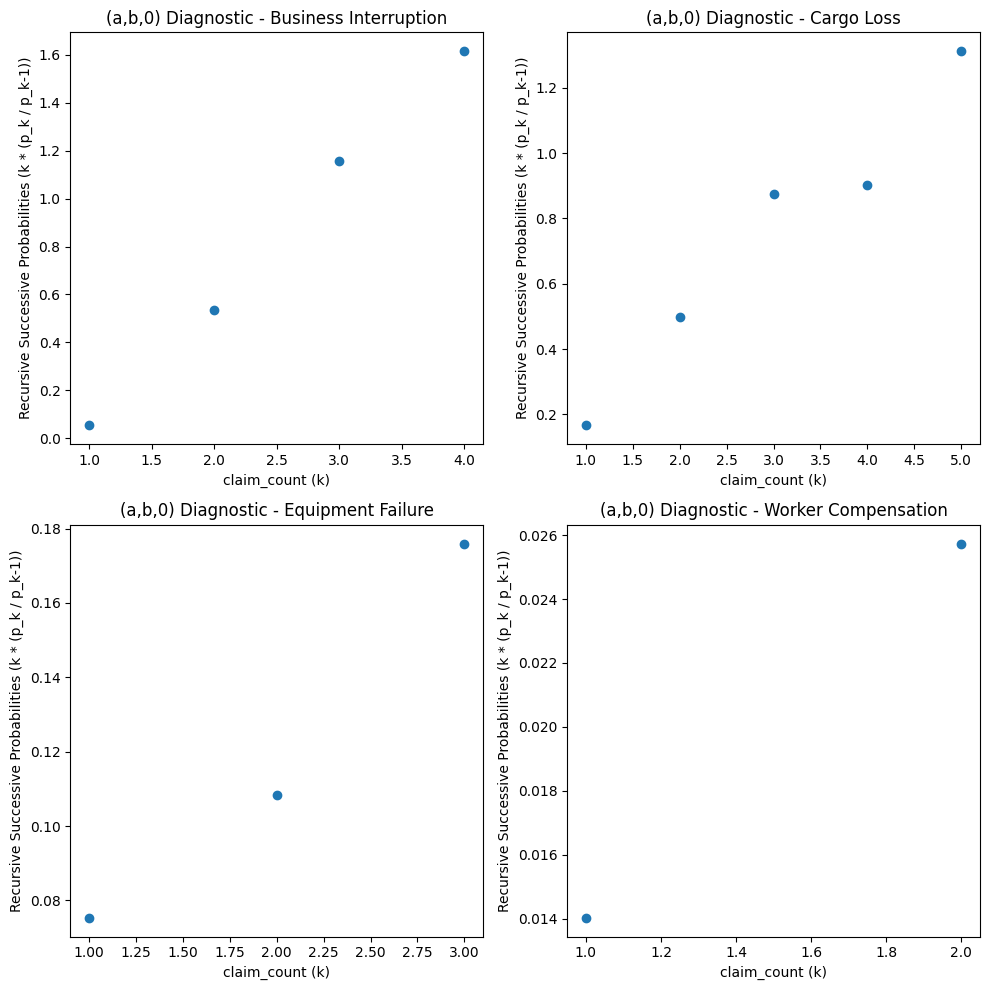

In [ ]:
# Set up the plot
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.flatten()

# Execute the functions on each hazard
for i, (name, hazard) in enumerate(frequency_datasets.items()):
    plot_ab0(hazard, name, ax = axes[i])
plt.tight_layout()
plt.show()

The (a,b,0) diagnostic indicated linear behavior for all frequency datasets.

The Distribution: Since the slope is positive and linear, this indicates that the data are all best modeled by a Negative Binomial distribution. However, the ratio difference between each point for equipment failure and worker compensation are very small, indcating a more horizontal slope line compared to business interruptions and cargo loss, meaning poisson model works better

This confirms the difference between variance and mean test done earlier: business interruptions and cargo loss have a overdispersed distribiton, while equipment failure and worker compensation almost have equal mean and variance, which is why the points had a very slight linear, but positive slope.

## Unifying Frequency Hazards

In [ ]:
freq_dataset = {'Business Interruptions': business_interruptions_freq, 'Cargo Loss': cargo_loss_freq,
                'Equipment Failure': equipment_failure_freq, 'Workers Compensation': worker_comp_freq}

freq = []

for name, hazard in freq_dataset.items():
    temp = hazard.copy()
    temp['hazard_type'] = name
    freq.append(temp)

# hazard_frequency
df_freq = pd.concat(freq, axis=0).reset_index(drop=True)
df_freq.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454277 entries, 0 to 454276
Data columns (total 41 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   policy_id                453491 non-null  object 
 1   station_id               234394 non-null  object 
 2   solar_system             328983 non-null  object 
 3   production_load          99702 non-null   float64
 4   energy_backup_score      99597 non-null   float64
 5   supply_chain_index       99715 non-null   float64
 6   avg_crew_exp             99595 non-null   float64
 7   maintenance_freq         99610 non-null   float64
 8   safety_compliance        99619 non-null   float64
 9   exposure                 453345 non-null  float64
 10  claim_count              454277 non-null  int64  
 11  hazard_type              454277 non-null  object 
 12  shipment_id              124468 non-null  object 
 13  cargo_type               124447 non-null  object 
 14  carg

In [ ]:
freq_dataset.keys()

dict_keys(['Business Interruptions', 'Cargo Loss', 'Equipment Failure', 'Workers Compensation'])

## Investigating Any Correlations Between Independent Variables

In [ ]:
# Detecting skewedness in financial variables - cargo value
data = df_freq['cargo_value'].dropna()

skewness = data.skew()
print(f'cargo_value: skewness = {skewness:.2f}')

# If skewness is high enough, created a logged version
if skewness > 1:
    df_freq['log_cargo_loss'] = np.log(df_freq['cargo_value'] + 1)  # +1 to avoid log(0)
    print('Applied log transform to cargo value')

    skewness_log = df_freq['log_cargo_loss'].skew()
    print(f'cargo_value_log: skewness = {skewness_log:.2f}')

    cargo_loss_freq['log_cargo_value'] = df_freq['log_cargo_loss']

cargo_value: skewness = 2.07
Applied log transform to cargo value
cargo_value_log: skewness = 0.58


In [ ]:
# Checking correlations with Variance Inflation Factor function
# It will be able to find correlation between variables within datasets and filter out the relevant and significant correlations

for name, hazard in freq_dataset.items():

    # Select numeric predictors only
    numeric_vars = hazard.select_dtypes(include='number').copy()

    numeric_vars = numeric_vars.drop(columns=['claim_count'], errors='ignore')

    # Add intercept
    numeric_vars["intercept"] = 1

    vif_data = pd.DataFrame()
    vif_data["Variable"] = numeric_vars.columns
    vif_data["VIF"] = [
        variance_inflation_factor(numeric_vars.dropna().values, i)
        for i in range(numeric_vars.shape[1])
    ]

    # Remove intercept & filter VIF > 3
    vif_filtered = vif_data[
        (vif_data["VIF"] > 3) & (vif_data["Variable"] != "intercept")
    ]

    if not vif_filtered.empty:
        print(f"\n{name}")
        print(vif_filtered.sort_values("VIF", ascending=False))


Cargo Loss
           Variable       VIF
3          distance  8.884210
4  transit_duration  8.611399


There is a high correlation between distance and transit variation, so therefore one must be dropped or not included when buidling the model.

### Model each hazard separately

# Severity

In [ ]:
severity_datasets = {
    "Business Interruption Claims Amount": business_interruptions_sev["claim_amount"],
    "Cargo Loss Claims Amount": cargo_loss_sev["claim_amount"],
    "Equipment Failure Claims Amount": equipment_failure_sev["claim_amount"],
    "Worker Compensation Claims Amount": worker_comp_sev["claim_amount"],
}

hazard_datasets_sev = {
    "Business Interruption": business_interruptions_sev,
    "Cargo Loss": cargo_loss_sev,
    "Equipment Failure": equipment_failure_sev,
    "Worker Compensation": worker_comp_sev,
}

## Shape of the amount distribution

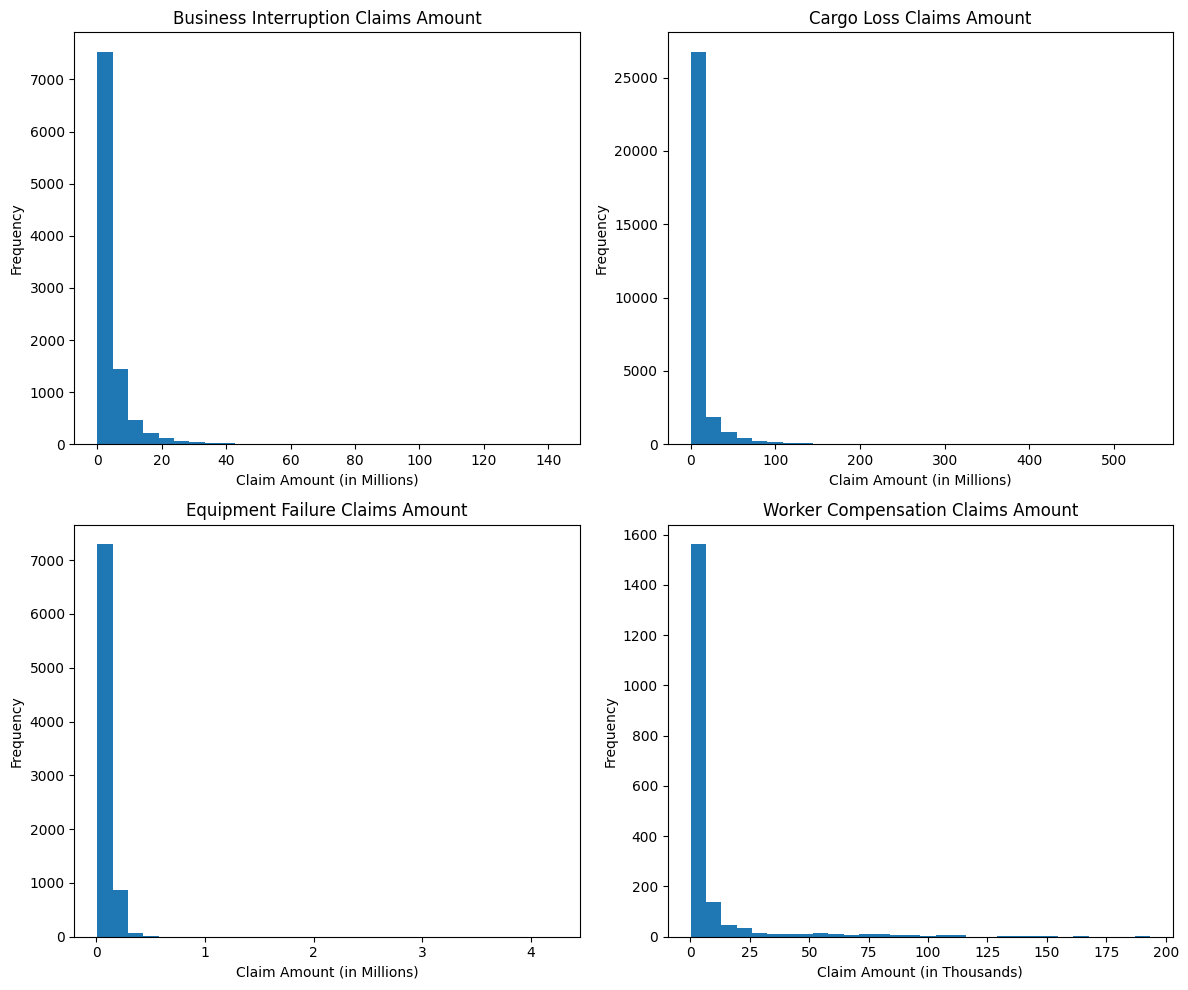

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (name, values) in zip(axes, severity_datasets.items()):

    if any(x in name for x in ["Business Interruption", "Cargo Loss", "Equipment Failure"]):
        divisor = 1_000_000
        unit = "Millions"
        ax.set_xlabel("Claim Amount (in Millions)")
    elif "Worker Compensation" in name:
        divisor = 1_000
        unit = "Thousands"
        ax.set_xlabel("Claim Amount (in Thousands)")
    else:
        divisor = 1
        unit = ""
        ax.set_xlabel("Claim Amount")

    ax.hist([v / divisor for v in values], bins=30)
    ax.set_title(name)

    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In all four categories the majority of claims are concentrated at very low values, while a few "black swan" events represent massive payouts, showing the data is very right skewed.

However, there is a significant difference in the magnitude of claims amount.
- Cargo Loss and Business Interruption see claims reaching into the hundreds of millions,
- whereas Worker Compensation claims are much smaller, topping out around $200,000.

Because the data is so skewed, standard normal distributions won't work here. We have to likely need to fit these to Log-Normal, Pareto, or Gamma distributions to accurately capture the risk of those high-value tail events.

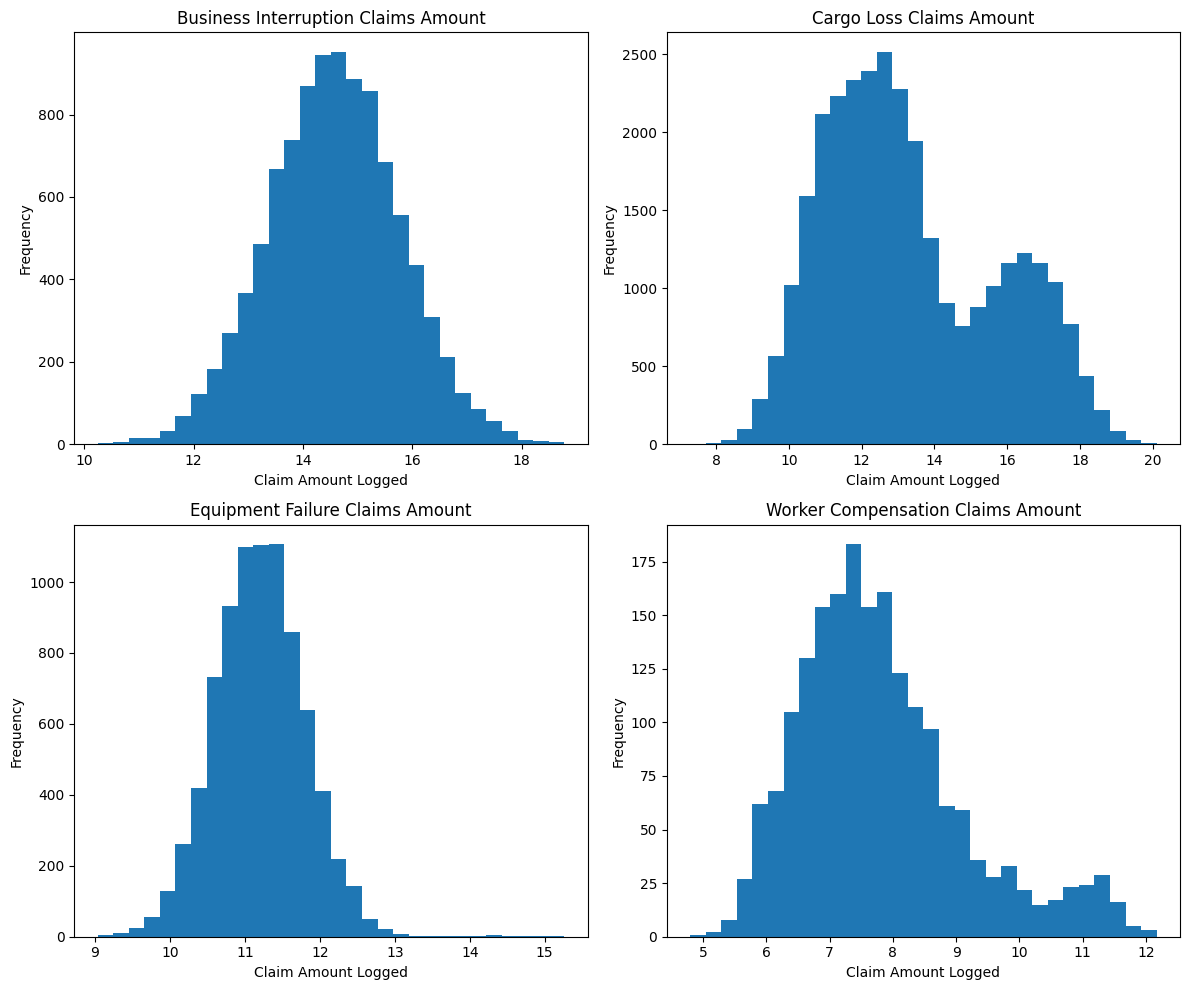

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for ax, (name, values) in zip(axes, severity_datasets.items()):

    logged_values = np.log(values.dropna())
    ax.hist(logged_values, bins=30)
    ax.set_title(name)
    ax.set_xlabel("Claim Amount Logged")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The x-axis (log scale) compresses the massive range of original values, making it easier to see the frequency of mid-to-high range claims that were previously invisible in the raw histograms.

Most categories, particularly Business Interruption and Equipment Failure, now resemble a "bell curve," which suggests the underlying data follows a Log-Normal distribution. However, the Cargo Loss and Worker Compensation plots show multiple peaks, indicating these datasets likely contain two different "sub-populations" of claims—such as routine minor losses versus catastrophic events.

Since the logged data looks approximately normal, it confirms that a Log-Normal distribution is a strong candidate for modeling your claim severity.

But for the bimodal shapes in Cargo Loss suggest that a single distribution might not be enough; it may need a Mixture Model to account for the two different types of claim behaviors seen in the data.

## Choosing the Correct Models

In [ ]:
# Tail Fit Validation: evaluates how well the Lognormal and Gamma distributions "predict" the extreme 1% of the losses

results = {}

for name, hazard in severity_datasets.items():

    data = hazard.dropna()

    # Lognormal Fit
    shape_ln, loc_ln, scale_ln = stats.lognorm.fit(data, floc=0)

    # 99% quantile
    q99_ln = stats.lognorm.ppf(0.99, shape_ln, loc=loc_ln, scale=scale_ln)

    # Gamma Fit
    shape_g, loc_g, scale_g = stats.gamma.fit(data, floc=0)

    q99_g = stats.gamma.ppf(0.99, shape_g, loc=loc_g, scale=scale_g)

    # Empirical 99%
    q99_emp = np.percentile(data, 99)

    results[name] = {
        "Empirical_99": q99_emp,
        "Lognormal_99": q99_ln,
        "Gamma_99": q99_g,
        "Lognormal_Ratio_99": q99_ln / q99_emp,
        "Gamma_Ratio_99": q99_g / q99_emp
    }

results_df = pd.DataFrame(results).T
results_df

,Empirical_99,Lognormal_99,Gamma_99,Lognormal_Ratio_99,Gamma_Ratio_99
Business Interruption Claims Amount,3.576933e+07,3.454675e+07,2.218283e+07,0.965820,0.620163
Cargo Loss Claims Amount,1.036779e+08,1.479514e+08,7.114110e+07,1.427030,0.686174
Equipment Failure Claims Amount,2.960549e+05,2.974375e+05,2.641309e+05,1.004670,0.892169
Worker Compensation Claims Amount,9.725864e+04,5.323720e+04,4.972512e+04,0.547378,0.511267


a ratio of 1.00 means the model perfectly predicted the extreme tail risk

For Equipment Failure, The Lognormal ratio is very close to 1, meaning the model is nearly identical to the real data at the 99th percentile. Lognormal can be used perfectly to predict the tail

THe same goes for Business Interruption. However, the Lognormal slightly underestimates the extreme risk by 4%. Still lognormal is much more superior than Gamma

Cargo Loss's lognormal model overestimates the risk here (Ratio: 1.42), predicting a 99th percentile much higher than what was seen. This is "conservative" from a risk perspective, would be holding more capital than necessary. The Gamma model, conversely, significantly underestimates the risk (Ratio: 0.68).

Worker Compensation: Both models fail significantly here, capturing only about 50-55% of the actual 99th percentile. This confirms the "bimodal" peak we saw in the logged histograms; a single standard distribution cannot account for the heavy tail in this specific dataset. It likely requires either a Pareto or Splice/Mixture Model here.

After weighing out simplicity and performance across different models, I have chosen:

- Equipment Failure & Business Interruption: Lognormal Model

- Cargo Loss: Spliced lognormal/Pareto Model

- Worker Compensation: Spliced Gamma/Pareto